# PRÁCTICA 2 SEMANA 1

**Se recomienda ejecutar los códigos de este jupyer notebook en la misma carpeta donde reside dicho documento, debido a la dependencia de ciertos documentos para el correcto uso del mismo.**

En primer lugar, vamos a importar las librerías necesarias y vamos a importar los csv necesarios. Defino los dataframes dos veces, esto está explicado más adelante.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snsz
from sklearn.linear_model import LinearRegression
import scipy.stats as stats
from sklearn.metrics import r2_score
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler


In [89]:
housing_test = pd.read_csv("dataset_housing_preprocesado_test.csv")
housing_train = pd.read_csv("dataset_housing_preprocesado_train.csv")
test = housing_test.drop(columns=["SalePrice"])
train = housing_train.drop(columns=["SalePrice"])

En esta semana 1 nos han proporcionado dos datasets, uno es el que entrena el modelo(train) y el otro es con el que comprueba si el modelo funciona correctamente(test), por ello tendremos que tratarlos de maneras diferentes.

In [90]:
test

,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,RoofStyle_Hip,RoofStyle_Other,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_Other,Foundation_PConc
0,69.0,7590,0,3,0,0,5,5,1962,1962,...,0,0,0,1,0,0,0,1,0,0
1,0.0,2117,0,3,0,0,6,5,2000,2000,...,0,0,0,1,0,0,0,0,0,1
2,62.0,10106,0,3,0,0,5,7,1940,1999,...,0,0,0,0,1,0,1,0,0,0
3,0.0,7050,0,3,0,0,7,5,2001,2001,...,0,0,0,0,1,0,0,0,0,1
4,80.0,11316,0,3,1,0,7,5,2002,2003,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,100.0,9500,0,3,1,0,6,6,1964,1978,...,0,0,1,0,0,0,0,1,0,0
331,124.0,11512,1,3,1,0,6,7,1959,2006,...,0,0,0,1,0,0,0,1,0,0
332,80.0,8000,0,3,1,0,5,4,1961,1961,...,0,0,0,0,1,0,0,1,0,0
333,89.0,12898,1,1,0,0,9,5,2007,2008,...,1,0,0,0,0,1,0,0,0,1


In [91]:
train

,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,RoofStyle_Hip,RoofStyle_Other,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_Other,Foundation_PConc
0,85.0,10574,0,3,0,0,8,5,2005,2006,...,0,0,0,0,1,0,0,0,0,1
1,50.0,9638,0,3,0,0,6,7,1919,1990,...,0,0,0,0,1,0,0,0,0,1
2,71.0,9230,0,3,1,0,5,8,1965,1998,...,1,0,0,1,0,0,0,1,0,0
3,80.0,16692,1,3,0,0,7,5,1978,1978,...,0,0,0,1,0,0,0,1,0,0
4,57.0,9245,2,3,0,0,5,5,1994,1995,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,70.0,8163,0,3,0,0,5,6,1959,1959,...,0,0,0,1,0,0,0,1,0,0
777,0.0,4500,0,3,3,0,6,5,1999,1999,...,1,0,0,1,0,0,0,0,0,1
778,80.0,17400,0,0,0,1,5,5,1977,1977,...,0,0,0,0,1,0,0,1,0,0
779,116.0,13474,0,3,0,0,7,5,1990,1991,...,0,0,0,1,0,0,0,1,0,0


Ahora, vamos a seguir los diferentes pasos para conseguir el mejor resultado.
#### PASO 1: Eliminación de variables colineales.
Si las variables de entrada al modelo son linealmente dependientes, la matriz de covarianza no es invertible. Como consecuencia, el problema de regresión por mínimos cuadrados no está bien definido.

Para abordar esto, vamos a hallar la matriz de covarianza y su rango para ver cuales son dependientes, buscamos hallar las variables dependientes para eliminarlas y definir correctamente el problema de regresión por mínimos de cuadrados, en este caso vamos a centrarnos para eliminar las variables dependientes de train, dado que nuestro modelo va a entrenar con todas las variables que no eliminemos el test tendrá que hacerlo también con todas las variables que no hemos eliminado del train. Es decir, vamos a eliminar las variables dependientes o colineales del train y esas mismas variables vamos a eliminarlas en el test.

Pero antes de eso, vamos a redefinir los datasets. Esto es debido a que el atributo a predecir, que en este caso podría ser el precio de la vivienda, no es una variable explicita como podría ser una fecha o un id sino la variable dependiente por defecto. Utilizar las matrices de correlación y de covarianza ha de servirnos únicamente para indicar la independencia entre las variables de los dataframes.

In [92]:
test_cov = test.cov()
train_cov = train.cov()
test_corr = test.corr()
train_corr = train.corr()

In [93]:
test_cov

,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,RoofStyle_Hip,RoofStyle_Other,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_Other,Foundation_PConc
LotFrontage,1333.093932,2.580101e+04,-2.963312,-2.231790,-4.334704,0.394048,6.581330,1.368532,-45.656359,29.094915,...,2.177272,0.432746,0.066360,-2.064215,1.682769,0.315086,0.496336,0.696309,-0.065511,-1.127134
LotArea,25801.005720,3.291676e+07,1109.692752,-1295.464251,982.611467,524.005309,337.492457,29.151792,-4514.926785,-6403.722540,...,237.312664,219.705362,0.252936,-107.612852,201.259130,-93.899214,-107.008222,292.201269,33.896202,-219.089248
LotShape,-2.963312,1.109693e+03,0.302672,-0.054384,0.135276,0.014899,0.118179,0.050961,2.610921,1.549692,...,-0.006640,0.003968,0.001412,0.000885,0.000331,-0.002628,-0.010635,-0.021360,0.001680,0.030315
LandContour,-2.231790,-1.295464e+03,-0.054384,0.390383,-0.012557,-0.089597,0.035258,-0.008803,1.218116,0.973456,...,-0.000581,-0.028868,-0.000670,0.020064,-0.017875,-0.001519,-0.009429,-0.005854,-0.006748,0.022031
LotConfig,-4.334704,9.826115e+02,0.135276,-0.012557,0.581428,-0.001010,0.040156,-0.044401,1.690643,0.842613,...,0.029332,0.006649,0.001233,-0.007338,0.018518,-0.012414,-0.014747,-0.016534,-0.001716,0.032997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MasVnrType_Stone,0.315086,-9.389921e+01,-0.002628,-0.001519,-0.012414,-0.003378,0.089177,-0.027733,1.554661,0.955715,...,0.004352,-0.001126,-0.000643,-0.018822,-0.031531,0.050997,-0.004022,-0.019752,-0.001448,0.025221
Foundation_BrkTil,0.496336,-1.070082e+02,-0.010635,-0.009429,-0.014747,0.001296,-0.042810,0.035168,-3.562472,-1.005452,...,-0.008759,0.001430,-0.000894,-0.026142,0.031057,-0.004022,0.069264,-0.035749,-0.002011,-0.031504
Foundation_CBlock,0.696309,2.922013e+02,-0.021360,-0.005854,-0.016534,0.008893,-0.239253,0.125078,-4.466887,-4.054652,...,0.010412,0.007954,0.006256,0.000357,0.013138,-0.019752,-0.035749,0.250246,-0.012870,-0.201627
Foundation_Other,-0.065511,3.389620e+01,0.001680,-0.006748,-0.001716,0.004299,-0.042238,-0.018357,-0.236143,-0.338011,...,0.000679,-0.000563,-0.000322,-0.000429,0.002199,-0.001448,-0.002011,-0.012870,0.026222,-0.011341


In [94]:
train_cov

,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,RoofStyle_Hip,RoofStyle_Other,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_Other,Foundation_PConc
LotFrontage,1153.768121,2.262386e+04,-3.678973,1.206437,-4.402456,-0.617978,5.039494,-1.938910,-11.017496,16.875357,...,1.084059,0.172859,0.046717,-0.354493,-0.462520,0.770296,-0.007533,-0.739822,0.001001,0.746354
LotArea,22623.863646,3.254955e+07,1113.929763,-1005.656748,531.714951,459.819932,1544.753213,-155.133172,6625.561474,5927.123047,...,188.939056,67.877330,32.708937,168.089417,-256.627425,55.829072,-60.588749,99.525373,-33.638854,-5.297771
LotShape,-3.678973,1.113930e+03,0.337930,-0.050080,0.124828,0.012110,0.157815,-0.036208,4.327138,2.193097,...,-0.004626,-0.002617,-0.000202,0.006949,-0.013500,0.006753,-0.020600,-0.029246,-0.003547,0.053393
LandContour,1.206437,-1.005657e+03,-0.050080,0.339735,0.012947,-0.089895,-0.008255,0.043009,0.557871,0.533021,...,0.003139,-0.004820,-0.002820,0.030170,-0.025815,-0.001535,0.001953,-0.005104,0.003693,-0.000543
LotConfig,-4.402456,5.317150e+02,0.124828,0.012947,0.684977,-0.006392,0.099440,0.047923,2.967244,1.948393,...,0.002691,0.001914,-0.001697,0.027176,-0.031166,0.005688,-0.009570,-0.018328,0.004659,0.023239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MasVnrType_Stone,0.770296,5.582907e+01,0.006753,-0.001535,0.005688,0.001246,0.087017,-0.027898,1.634742,0.985265,...,0.006157,-0.001264,-0.000451,-0.022300,-0.042795,0.065547,-0.006501,-0.014626,-0.001625,0.022752
Foundation_BrkTil,-0.007533,-6.058875e+01,-0.020600,0.001953,-0.009570,0.000046,-0.036506,0.069073,-4.390021,-1.121923,...,-0.012382,0.000909,-0.000591,-0.027911,0.035003,-0.006501,0.083798,-0.044322,-0.002127,-0.037349
Foundation_CBlock,-0.739822,9.952537e+01,-0.029246,-0.005104,-0.018328,0.004299,-0.299593,0.118410,-4.046691,-3.697782,...,0.020071,0.002920,0.003332,0.006926,0.004368,-0.014626,-0.044322,0.249926,-0.011080,-0.194524
Foundation_Other,0.001001,-3.363885e+01,-0.003547,0.003693,0.004659,-0.001271,-0.029960,-0.012860,-0.367698,-0.337853,...,-0.003416,0.000868,-0.000148,-0.006016,0.007789,-0.001625,-0.002127,-0.011080,0.022545,-0.009337


In [95]:
test_range = np.linalg.matrix_rank(test_cov)
train_range = np.linalg.matrix_rank(train_cov)
print(f"Test:{test_cov.shape}, Train {train_cov.shape}")
print(f"Test {test_range}, Train {train_range}")

Test:(152, 152), Train (152, 152)
Test 131, Train 139


Vemos que tanto Train como Test tienen el mismo número de variables: 153 (contando con la variable a predecir). Sin embargo, a la hora de ajustar las variables usando los rangos de las matrices de covarianzas vemos que el dataset Train tiene 12 variables dependientes y el dataset Test tiene 21 variables dependientes. Vamos a hallar cuales son estas 12 variables y a eliminarlas de ambos dataframes utilizando la matriz de correlación. 

In [96]:
# Seguimos el pseudocódigo del pdf:
# 1,2. Definimos cols y calculamos rank
cols = list(train.columns)
rank = np.linalg.matrix_rank(train[cols].cov())
# 3 Generamos un bucle while para que lo haga para cada columna
i = 0
while i < len(cols):
    col = cols[i]
    # Creamos una copia de las columnas sin la actual
    cols2 = cols.copy()
    cols2.remove(col)
    # Calculamos el rango sin esa columna
    train2 = train[cols2]
    rank2 = np.linalg.matrix_rank(train2.cov())
    # Si el rango no cambia, eliminamos definitivamente la columna
    if rank == rank2:
        cols = cols2
        i = 0
    else:
        i += 1
        
# Ahora eliminamos las variables dependientes redefiniendo el dataset
train = train[cols]
test = test[cols]
# Comprobamos
print(train.shape)
print(test.shape)
# Comprobamos el rango otra vez.
test_cov = test.cov()
train_cov = train.cov()
test_range = np.linalg.matrix_rank(test_cov)
train_range = np.linalg.matrix_rank(train_cov)
print(f"Test:{test_cov.shape}, Train {train_cov.shape}")
print(f"Test {test_range}, Train {train_range}")

(781, 139)
(335, 139)
Test:(139, 139), Train (139, 139)
Test 130, Train 139


Ahora tenemos nuestros datasets sin nuestra variable a predecir y sin variables colineales. Tenemos un dataset de entrenamiento con solo variables independientes. Por tanto, podemos pasar al Paso 2 de la práctica.

#### PASO 2: Construcción de un primer modelo
Primero, vamos a construir un modelo de regresión lineal usando sklearn y vamos a calcular su coeficiente de determinación R2 en ambos datasets. Esto lo realizamos para evaluar si la reducción de variables ha mantenido la capacidad predictiva del modelo. Un R2 similar al original indica que las variables eliminadas eran redundantes, mientras que un valor muy diferente puede sugerir pérdida de información relevante.

In [97]:
# Vamos a definir el modelo lineal utilizando ambos datasets.
# Utilizamos test y train para definir el eje X porque no tiene el atributo "SalePrice",
# que es el atributo a predecir o eso creemos y vamos a entrenar el modelo.
X_test = test
Y_test = housing_test["SalePrice"]
X_train = train
Y_train = housing_train["SalePrice"]
print(X_test.shape,Y_test.shape,X_train.shape,Y_train.shape)
modelo = LinearRegression()
modelo.fit(X_train,Y_train)

(335, 139) (335,) (781, 139) (781,)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [98]:
# Hallamos el coeficiente R2 de test y train
print(modelo.score(X_train,Y_train))
print(modelo.score(X_test,Y_test))

0.9424614967584222
0.8768548653213977


El modelo de regresión lineal alcanza un coeficiente de determinación R2 = 0.94 en el conjunto de entrenamiento y R2 = 0.88 en el conjunto de test.

Dado que ambos valores son elevados y la diferencia entre ellos es moderada, no hay sobreajuste. El modelo logra un equilibrio razonable de  ajuste. Ahora vamos a ver si nuestro modelo consigue un precio estimado con el modelo de training y vamos a visualizarlo creando un scatter plot.

39300 52000 381000 755000


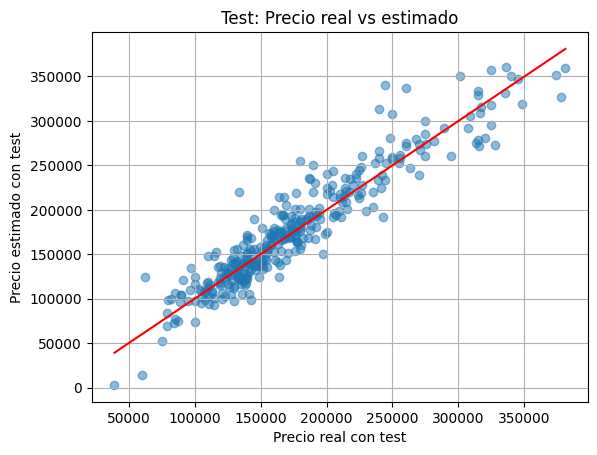

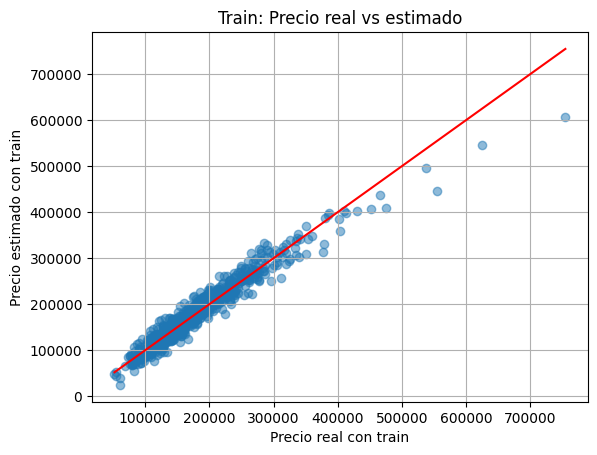

In [99]:
# Vamos a definir las predicciones y visualizarlas mediante un scatter plot
train_predict = modelo.predict(X_train)
test_predict = modelo.predict(X_test)
min_test = min(Y_test) 
max_test = max(Y_test)
min_train = min (Y_train)
max_train = max(Y_train)
print(min_test,min_train,max_test,max_train)

plt.scatter(Y_test, test_predict, alpha=0.5)
plt.plot([min_test,max_test], [min_test,max_test], "r")
plt.xlabel("Precio real con test")
plt.ylabel("Precio estimado con test")
plt.title("Test: Precio real vs estimado")
plt.grid()
plt.show()

plt.scatter(Y_train, train_predict, alpha=0.5)
plt.plot([min_train,max_train], [min_train,max_train], "r")
plt.xlabel("Precio real con train")
plt.ylabel("Precio estimado con train")
plt.title("Train: Precio real vs estimado")
plt.grid()
plt.show()

Con los scatter plots, quitando de lado los outliers, podemos ver que los puntos o datos no se alejan de la diagonal. Al agruparse junto a la diagonal podemos concluir que el modelo ajusta bien. Ahora vamos a hallar los coeficientes del modelo lineal ajustado y su termino independiente. Con estos coeficientes vamos a calcular las predicciones nuevamente y vamos a ver si coinciden con las de modelo.predict().

In [100]:
print(modelo.coef_)
print(modelo.intercept_)

[ 1.98310774e+01  1.43394341e+00  6.74551200e+02 -1.32667432e+03
 -9.25205327e+02 -5.09840585e+03  1.00473734e+04  6.06884698e+03
  4.18683880e+02  2.95788856e+01 -2.05587845e+04  5.38934070e+01
  8.42340621e+03 -1.38229301e+03  3.67702933e+02 -1.00582897e+04
  5.86359057e+03 -4.57590380e+02  3.46295713e+02 -1.37207305e+01
 -1.82676053e+01  4.24106233e+01 -3.38782436e+03  1.39384439e+03
 -8.13382118e+02  2.80243996e+03  2.44795820e+01  2.98723358e+00
  5.24245164e+01  3.20726434e+03  2.10339501e+03 -4.39138159e+03
 -2.00139652e+03 -5.00934845e+03 -6.55846646e+03  2.76513562e+03
  2.78975829e+02  3.54322909e+03  7.41922905e+03 -2.63601287e+03
 -1.33468285e+03  3.81337604e+03  1.14406386e+03  2.60932299e+03
 -5.33100309e+00  6.59532062e+03 -6.14270423e+03  2.98248556e+03
  6.55089097e+00  2.84130921e+01  9.07152461e+00  4.15998133e-01
  4.26622704e+01 -1.80924521e+01  8.79281691e+03 -3.34259154e+02
  1.11095662e-01 -6.61087217e+03 -7.74134925e+03 -1.54719140e+04
 -1.55684037e+03 -8.88792

Ahora, para calcular manualmente la predicción tenemos que seguir $\hat{y} = X \cdot \beta + \beta_0$. Qué es la fórmula que utiliza sklearn para hacer el modelo predictivo. Donde $\beta_0$ es el término independiente y todas las demás betas son los coeficientes. 

In [101]:
# y = X * ß + ß_0. Utilizamos np.dot para calcular la multiplicación con cada coeficiente
y_pred_manual = np.dot(X_test, modelo.coef_) + modelo.intercept_

# Comprobamos igualdad con np.allclose que comprueba 
# si todos los valores son iguales permitiendo pequeñas diferenia numéricas.
np.allclose(test_predict, y_pred_manual)

True

Vemos que el modelo predictivo coincide con el modelo manual que hemos creado. Ahora vamos a ver si los residuos siguen una distribución gaussiana con un histograma y un qq-plot.

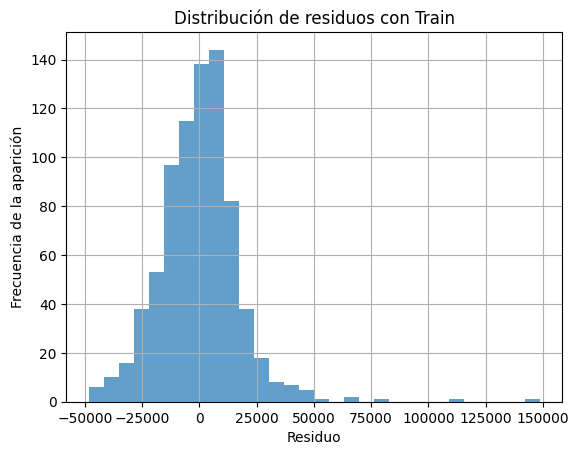

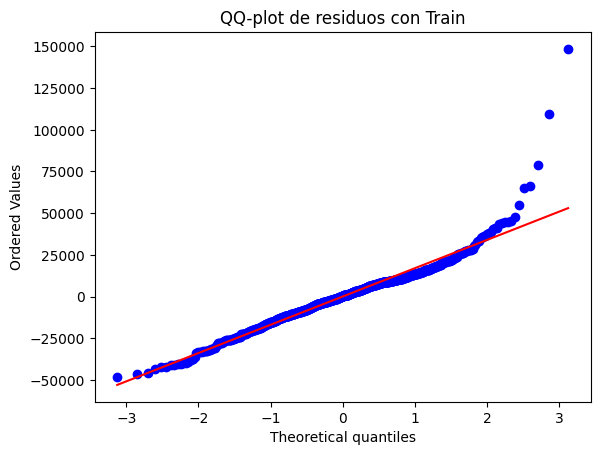

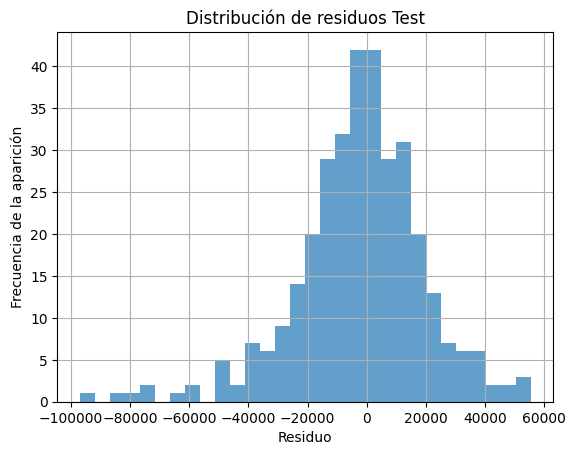

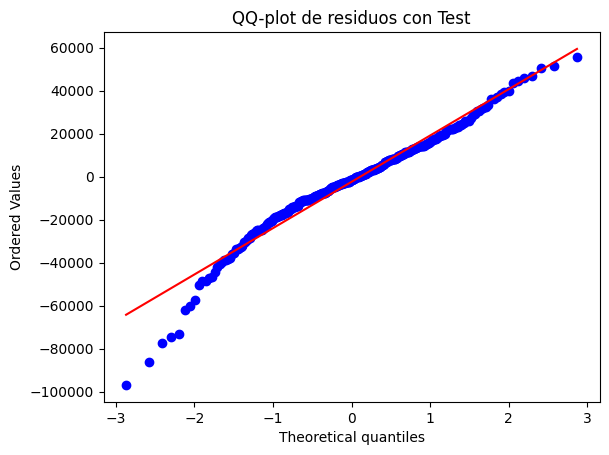

In [102]:
# Obtenemos los residuos (Valor real - valor predictivo)
residuos_train = Y_train - modelo.predict(X_train)
residuos_test = Y_test - modelo.predict(X_test)

# Histograma y qq-plot TRAIN
plt.hist(residuos_train, bins=30, alpha=0.7)
plt.title("Distribución de residuos con Train")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia de la aparición")
plt.grid()
plt.show()

stats.probplot(residuos_train, dist="norm", plot=plt)
plt.title("QQ-plot de residuos con Train")
plt.show()

# Histograma y qq-plot TEST
plt.hist(residuos_test, bins=30, alpha=0.7)
plt.title("Distribución de residuos Test")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia de la aparición")
plt.grid()
plt.show()

stats.probplot(residuos_test, dist="norm", plot=plt)
plt.title("QQ-plot de residuos con Test")
plt.show()

Para que siga una distribución gaussiana tiene que darse en los histogramas una especie de relación a una campana y en cuanto a los qq-plots la mayoría de los valores se han de solapar entorno a la diagonal. Como podemos ver todo lo mencionado se cumple, así que por tanto si que sigue una distribución gaussiana tanto en test como en train.

Para seguir vamos a explorar el efecto de transformar de manera no lineal 
el target usando la transformación logarítmica, utilizando un histograma del target ("SalePrice") sin transformar y comparándolo con el transformado.

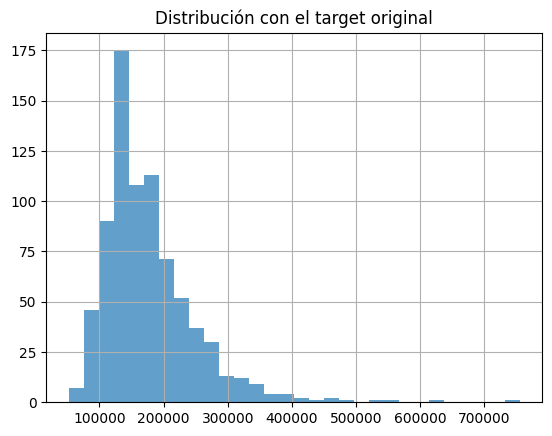

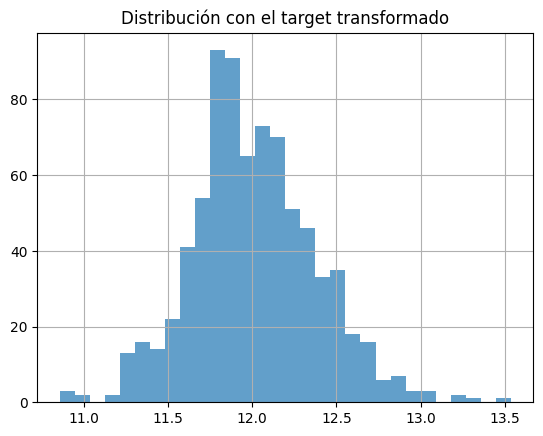

In [103]:
# Histograma con el target original.
plt.hist(Y_train, bins = 30, alpha = 0.7)
plt.title("Distribución con el target original")
plt.grid()
plt.show()
# Histograma con el target transformado.
plt.hist(np.log(Y_train), bins = 30, alpha = 0.7)
plt.title("Distribución con el target transformado")
plt.grid()
plt.show()

Fijándonos en el histograma del target sin modificar vemos que la distribución recae en la parte de la izquierda, teniendo más sentido ya que suele haber más casas baratas que caras. Por otra parte, fijándonos en el modelo logarítmico el histograma sigue mucho más de cerca una forma de distribución normal.

Por último, vamos a volver a crear un modelo lineal, esta vez vamos a utilizar la versión logarítmica con el atributo target transformado. Para ello tendremos que volver a convertir las predicciones a dólares y volviendo a hallar el R2

In [104]:
# Creamos el modelo lineal con train.
modelo_log = LinearRegression()
modelo_log.fit(X_train, np.log(Y_train))
# Creamos las predicciones y ajustamos el target.
prediction_train_log = np.exp(modelo_log.predict(X_train))
prediction_test_log = np.exp(modelo_log.predict(X_test))
#Calculamos R2 con r2_score
r2_train_log = r2_score (Y_train,prediction_train_log)
r2_test_log =r2_score(Y_test, prediction_test_log)

print(r2_test_log,r2_train_log)

0.9296046419335563 0.9706299000102827


**Los valores R2 de nuestro primer modelo eran:**

Train: 0.9424614967584221

Test: 0.8768548653213977

**Los valores R2 de nuestro modelo transformado son:**

Train:0.9706299000102838

Test: 0.9296046419335727

Dado que los datos de R2 de nuestro modelo logarítmico están más cerca de 1, quiere decir que son mucho mejores que los de nuestro modelo original. Por tanto y en conclusión, si tuvieramos que elegir un modelo para predecir el precio de venta de una vivienda utilizaría el modelo transformado, ya que se acerca más a la realidad.

# PRÁCTICA 2 SEMANA 2

#### Paso 1: Construcción de un modelo lineal con librería statsmodels
Ahora, hemos de repetir el mismo proceso de la semana 1 pero utilizando otra librería statsmodels la cual vamos a importar a continuación. Para construir este modelo lineal vamos a utilizar diferentes herramientas y hallar ciertas estadísticas para la comprobación de la eficacia y eficiencia del modelo.

In [105]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)


# Definir el modelo y lo entrenamos
modelo_sm = sm.OLS(Y_train, X_train_sm)
modelo_ajustado = modelo_sm.fit()
predicciones_test = modelo_ajustado.predict(X_test_sm)

coef_sm = modelo_ajustado.params.drop('const').values
coef_sklearn = modelo.coef_

print(modelo_ajustado.params.values)
print("")
print(modelo_ajustado.rsquared)
print(r2_score(Y_test, predicciones_test))
print(np.allclose(coef_sm, coef_sklearn))

[-9.51648658e+05  1.98310774e+01  1.43394341e+00  6.74551200e+02
 -1.32667432e+03 -9.25205327e+02 -5.09840585e+03  1.00473734e+04
  6.06884698e+03  4.18683880e+02  2.95788856e+01 -2.05587845e+04
  5.38934070e+01  8.42340621e+03 -1.38229301e+03  3.67702933e+02
 -1.00582897e+04  5.86359057e+03 -4.57590380e+02  3.46295713e+02
 -1.37207305e+01 -1.82676053e+01  4.24106233e+01 -3.38782436e+03
  1.39384439e+03 -8.13382118e+02  2.80243996e+03  2.44795820e+01
  2.98723358e+00  5.24245164e+01  3.20726434e+03  2.10339501e+03
 -4.39138158e+03 -2.00139652e+03 -5.00934845e+03 -6.55846646e+03
  2.76513562e+03  2.78975829e+02  3.54322909e+03  7.41922905e+03
 -2.63601287e+03 -1.33468285e+03  3.81337604e+03  1.14406386e+03
  2.60932299e+03 -5.33100309e+00  6.59532062e+03 -6.14270423e+03
  2.98248556e+03  6.55089097e+00  2.84130921e+01  9.07152461e+00
  4.15998133e-01  4.26622704e+01 -1.80924521e+01  8.79281691e+03
 -3.34259154e+02  1.11095662e-01 -6.61087217e+03 -7.74134925e+03
 -1.54719140e+04 -1.55684

Tenemos que:

- Sklearn:
  
0.9424614967584221

0.8768548653213977

- StatsModels:

0.9424614967584221

0.8768548653212765

Comparando los valores no hay diferencia entre los modelos, tampoco vemos diferencias entre los coeficientes ni tampoco en los coeficientes de determinación. También vamos a ver el QQ-plot.

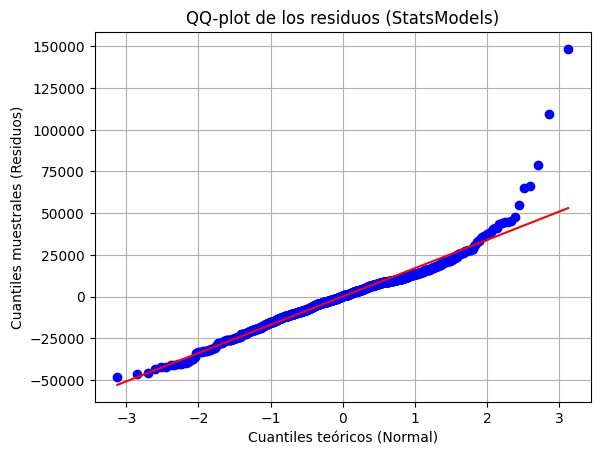

In [106]:
# Hallamos los residuos
residuos = modelo_ajustado.resid

# QQ-plot
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQ-plot de los residuos (StatsModels)")
plt.xlabel("Cuantiles teóricos (Normal)")
plt.ylabel("Cuantiles muestrales (Residuos)")
plt.grid()
plt.show()

In [ ]:
# Información estadística del modelo 
modelo_ajustado.summary()

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     75.54
Date:                Thu, 30 Oct 2025   Prob (F-statistic):          1.43e-322
Time:                        00:08:37   Log-Likelihood:                -8741.7
No. Observations:                 781   AIC:                         1.776e+04
Df Residuals:                     641   BIC:                         1.842e+04
Df Model:                         139                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -9.516e+05 

In [108]:
# Información detallada
std_errors = modelo_ajustado.bse
# p-values
p_values = modelo_ajustado.pvalues
# Intervalo confianza (95%)
conf_intervals = modelo_ajustado.conf_int(alpha=0.05)

summary_df = pd.DataFrame({
    'coef': modelo_ajustado.params,
    'std_error': std_errors,
    'p_value': p_values,
    'CI_lower': conf_intervals[0],
    'CI_upper': conf_intervals[1]
})

print(summary_df)


                            coef      std_error       p_value      CI_lower  \
const             -951648.657512  221630.764228  2.028009e-05 -1.386859e+06   
LotFrontage            19.831077      25.833603  4.429798e-01 -3.089764e+01   
LotArea                 1.433943       0.196202  8.067459e-13  1.048668e+00   
LotShape              674.551200    1596.311730  6.727518e-01 -2.460081e+03   
LandContour         -1326.674317    1874.629527  4.793891e-01 -5.007831e+03   
...                          ...            ...           ...           ...   
MasVnrType_None     10936.121175    9659.663320  2.579976e-01 -8.032287e+03   
MasVnrType_Stone     3907.994401   10072.774578  6.981626e-01 -1.587163e+04   
Foundation_CBlock   -1790.732683    3892.908439  6.456732e-01 -9.435127e+03   
Foundation_Other    -1111.320306    7572.645252  8.833719e-01 -1.598151e+04   
Foundation_PConc     3673.647765    4163.735418  3.779474e-01 -4.502562e+03   

                        CI_upper  
const           

Entonces las variables con p-valores mayores a 0.05 y cuyos intervalos de confianza incluyen el cero no aportan información estadísticamente significativa al modelo.
En este caso, destacan como no relevantes variables como LotFrontage, LotShape, LandContour, YearRemodAdd, GarageArea, Fence y varias dummies de MSSubClass, MSZoning y Neighborhood.

In [109]:
## Asignamos el nivel de significancia y ponemos como minimo de variables 1. creamos tambien un ocntenedor para las variables iliminadas
acc_level = 0.05
min_vars = 1
cols = list(X_train.columns)
eliminadas = []
#El maximo numero de iteraciones
max_iter = max(len(cols) - min_vars, 0)

for _ in range(max_iter):
    X_train_sm = sm.add_constant(X_train[cols], has_constant='add')         #Ajustamos modelo con las columnas actuales
    modelo = sm.OLS(Y_train, X_train_sm).fit()
    pvals = modelo.pvalues.drop('const', errors='ignore')                   #p-values de las variables explicativas sin la constante
    if pvals.empty:                                                         #Nos daba error porque en algunos casos no hay pvals
        break
    worst_p = pvals.max()
    worst_feature = pvals.idxmax()
    if worst_p <= acc_level:                                                # Que pare cuando ya sean todas significativas a partir del acclevel definido
        break
    if len(cols) <= min_vars:
        break




# Eliminar la peor variable


    cols.remove(worst_feature)
    eliminadas.append((worst_feature, float(worst_p)))


print("seleccionadas")                                                      #Estas son las que tenian el mejor p-vaule
print(cols)


## Y vamos ya con nuestro modelo


X_train_sel = sm.add_constant(X_train[cols], has_constant='add')
X_test_sel  = sm.add_constant(X_test[cols],  has_constant='add')

modelo_final = sm.OLS(Y_train, X_train_sel).fit()
pred_train = modelo_final.predict(X_train_sel)
pred_test  = modelo_final.predict(X_test_sel)

#Le definimos klas r-squared para que puedan calcularlas en el OLS
r2_train = r2_score(Y_train, pred_train)
r2_test  = r2_score(Y_test,  pred_test)


print("\nR² train:", r2_train)
print("R² test:", r2_test)

if eliminadas:
    print("\nOrden de eliminación (variable, p-value):")
    for var, pv in eliminadas:
        print(f"{var}: {pv:.4f}")
else:
    print("Todas las variables son significativas")




# Y ya lo podemos observar
print(modelo_final.summary())


seleccionadas
['LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'RoofMatl_CompShg', 'MasVnrArea', 'ExterQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenQual', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt_gt_1990', 'ScreenPorch', 'Condition_Feedr', 'Condition_RRAe', 'Exterior_BrkFace', 'Exterior_CemntBd', 'Exterior_Stucco', 'MSSubClass_45', 'MSSubClass_80', 'MSZoning_RL', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NWAmes', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Timber', 'Neighborhood_Veenker', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'HouseStyle_1Story', 'HouseStyle_SLvl', 'MasVnrType_None']

R² train: 0.9363216731958053
R² test: 0.8852941222456706

Orden de eliminación (variable, p-value):
3S

**Paso 2B**
Lasso y Ridge piden que esten estandarizadas las varibles


In [112]:
escalar = StandardScaler()
X_train_escalar = escalar.fit_transform(X_train)
X_test_escalar = escalar.transform(X_test)

##LASSO 
#Usamos validaciOn cruzada para alpha
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_escalar, Y_train)

#Guardamos los coeficientes
coef_lasso = pd.Series(lasso.coef_, index=X_train.columns)



# Identificamos las variablescon 0
vars_cero_lasso = coef_lasso[coef_lasso == 0].index.tolist()

print("LASSO")
print(f"Mejor alpha: {lasso.alpha_}")
print(f"Variables con coeficiente = 0 ({len(vars_cero_lasso)} variables):")
print(vars_cero_lasso)

# Calculamos los R^2 en train y test
r2_train_l = lasso.score(X_train_escalar, Y_train)
r2_test_l = lasso.score(X_test_escalar, Y_test)

print(f"R^2 training: {r2_train_l:.4f}")
print(f"R^2 test: {r2_test_l:.4f}")

#Ridge
# Hacemos lo mismo pero con regresión Ridge
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_escalar, Y_train)

# Guardamos coeficientes y métricas
coef_r = pd.Series(ridge.coef_, index=X_train.columns)

print("RIDGE")
print(f"Mejor alpha: {ridge.alpha_}")
print(f"R^2 training: {ridge.score(X_train_escalar, Y_train):.4f}")
print(f"R^2 test: {ridge.score(X_test_escalar, Y_test):.4f}")

LASSO
Mejor alpha: 335.27687649444994
Variables con coeficiente = 0 (40 variables):
['ExterCond', 'BsmtQual', 'BsmtFinType2', 'Heating_GasA', 'CentralAir', 'Electrical', 'LowQualFinSF', 'HalfBath', 'TotRmsAbvGrd', 'GarageQual', 'GarageCond', '3SsnPorch', 'PoolArea', 'Fence', 'MiscVal', 'Condition_PosA', 'Condition_RRNn', 'Exterior_AsphShn', 'Exterior_MetalSd', 'Exterior_VinylSd', 'Exterior_WdShing', 'MSSubClass_180', 'MSSubClass_60', 'MSSubClass_70', 'MSSubClass_80', 'MSSubClass_85', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'Neighborhood_BrDale', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_OldTown', 'Neighborhood_SawyerW', 'HouseStyle_1Story', 'HouseStyle_2.5Fin', 'HouseStyle_2Story', 'RoofStyle_Hip', 'MasVnrType_Stone']
R^2 training: 0.9374
R^2 test: 0.8922
RIDGE
Mejor alpha: 33.9322177189533
R^2 training: 0.9398
R^2 test: 0.8874
